# 네이버 데이터랩 브랜딩 검색 관심도 시계열 분석

## 1. 분석 목적

이 분석은 2023년 1월부터 2026년 7월까지의 주간 검색 관심도 자료를 이용해 `퍼스널브랜딩`, `이미지메이킹`, `스피치`의 흐름을 비교한다. 단순히 높은 값을 찾는 데 그치지 않고 다음을 확인한다.

- 장기적인 관심 흐름: 4주 이동평균
- 관심이 크게 움직인 시점: 전주 대비 증감량과 변화율
- 반복 가능성이 있는 시기: 월별 평균과 연도×월 패턴
- 콘텐츠 주제의 상대적 우선순위 변화: 4주 이동평균 순위

> 네이버 데이터랩 값은 실제 검색 건수가 아니라 선택한 조회 조건 안의 상대적 관심도다. 따라서 이 노트북에서는 절대 검색량이나 원인을 추정하지 않고, 데이터에서 직접 확인되는 변화와 패턴만 `Fact`로 정리한다.

## 2. 필요한 라이브러리 불러오기

`pandas`는 표 형태 데이터 처리, `numpy`는 수치 계산, `matplotlib`은 그래프 작성에 사용한다. `openpyxl`은 pandas가 XLSX 파일을 읽을 때 사용하는 엔진이다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager, patches

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")

# Windows에서는 맑은 고딕을 우선 사용한다. 없으면 사용 가능한 후보 글꼴로 대체한다.
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
selected_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = selected_font
plt.rcParams["axes.unicode_minus"] = False
print(f"사용 글꼴: {selected_font}")

사용 글꼴: Malgun Gothic


## 3. `data/datalab.xlsx` 불러오기

원본 파일에는 표 위에 조회 조건 6행이 있다. 우선 `header=None`으로 전체 셀을 그대로 읽어 원본 구조를 보존한다. 원본 파일에는 쓰기 작업을 하지 않는다.

In [2]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "datalab.xlsx"
IMAGE_DIR = PROJECT_DIR / "images"
IMAGE_DIR.mkdir(exist_ok=True)

sheet_names = pd.ExcelFile(DATA_PATH, engine="openpyxl").sheet_names
raw = pd.read_excel(DATA_PATH, sheet_name="개요", header=None, engine="openpyxl")

print(f"시트 목록: {sheet_names}")
print(f"원본을 읽은 크기: {raw.shape[0]}행 × {raw.shape[1]}열")

시트 목록: ['개요']
원본을 읽은 크기: 193행 × 6열


C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 4. 원본 데이터 구조 확인

1~6행은 URL과 조회 조건, 7행은 실제 헤더, 8행부터는 주간 데이터인지 확인한다.

In [3]:
print("상단 조회 조건과 실제 헤더:")
display(raw.head(8))
print("마지막 데이터 행:")
display(raw.tail(3))

상단 조회 조건과 실제 헤더:


,0,1,2,3,4,5
0,url,http://datalab.naver.com/keyword/trendResult.n...,NaN,NaN,NaN,NaN
1,주제,통검,NaN,NaN,NaN,NaN
2,범위,합계,NaN,NaN,NaN,NaN
3,기간,주간 : 2023-01 ~ 2026-07,NaN,NaN,NaN,NaN
4,성별,"전체(여성,남성)",NaN,NaN,NaN,NaN
5,연령대,전체,NaN,NaN,NaN,NaN
6,날짜,퍼스널브랜딩,날짜,이미지메이킹,날짜,스피치
7,2023-01-02,34.27547,2023-01-02,16.85907,2023-01-02,100.0


마지막 데이터 행:


,0,1,2,3,4,5
190,2026-07-06,5.8121,2026-07-06,4.12022,2026-07-06,37.04219
191,2026-07-13,4.69745,2026-07-13,4.29936,2026-07-13,37.30095
192,2026-07-20,7.10589,2026-07-20,4.37898,2026-07-20,37.34076


## 5. 상단 설명 행 제거 및 실제 헤더 적용

엑셀 7행의 실제 헤더에는 `날짜`가 세 번 반복된다. 원래 헤더를 확인한 뒤, 각 날짜가 어느 키워드에 대응하는지 알 수 있도록 고유한 이름을 부여한다.

In [4]:
original_headers = raw.iloc[6, :6].tolist()
expected_headers = ["날짜", "퍼스널브랜딩", "날짜", "이미지메이킹", "날짜", "스피치"]
assert original_headers == expected_headers, "예상한 헤더 구조와 실제 파일이 다릅니다."

source_columns = [
    "날짜_퍼스널브랜딩", "퍼스널브랜딩",
    "날짜_이미지메이킹", "이미지메이킹",
    "날짜_스피치", "스피치",
]
clean_source = raw.iloc[7:, :6].copy()
clean_source.columns = source_columns
clean_source = clean_source.reset_index(drop=True)

print(f"원래 헤더: {original_headers}")
print(f"설명 행 제거 후 크기: {clean_source.shape}")
display(clean_source.head())

원래 헤더: ['날짜', '퍼스널브랜딩', '날짜', '이미지메이킹', '날짜', '스피치']
설명 행 제거 후 크기: (186, 6)


,날짜_퍼스널브랜딩,퍼스널브랜딩,날짜_이미지메이킹,이미지메이킹,날짜_스피치,스피치
0,2023-01-02,34.27547,2023-01-02,16.85907,2023-01-02,100.0
1,2023-01-09,33.9371,2023-01-09,16.44108,2023-01-09,95.72054
2,2023-01-16,28.50318,2023-01-16,15.70461,2023-01-16,94.6656
3,2023-01-23,30.49363,2023-01-23,14.19187,2023-01-23,93.63057
4,2023-01-30,33.24044,2023-01-30,12.79856,2023-01-30,88.97292


## 6. 세 날짜 열이 모두 동일한지 다시 검증

날짜 열을 하나로 합치기 전에 행별 값이 완전히 같은지 검사한다. 하나라도 다르면 통합하지 않고 오류를 발생시킨다.

In [5]:
date_columns = ["날짜_퍼스널브랜딩", "날짜_이미지메이킹", "날짜_스피치"]
date_match_by_row = clean_source[date_columns].nunique(axis=1, dropna=False).eq(1)
date_mismatch_count = int((~date_match_by_row).sum())

print(f"세 날짜 열이 동일한 행: {int(date_match_by_row.sum())}개")
print(f"세 날짜 열이 다른 행: {date_mismatch_count}개")
assert date_mismatch_count == 0, "세 날짜 열에 서로 다른 값이 있습니다."

세 날짜 열이 동일한 행: 186개
세 날짜 열이 다른 행: 0개


## 7~9. 날짜 열 통합, datetime 변환, 관심도 숫자형 변환

동일함이 확인된 날짜 열 하나만 남긴다. `errors='coerce'`는 변환할 수 없는 값을 `NaN` 또는 `NaT`로 바꾸므로, 변환 직후 실패 개수를 검사한다.

In [6]:
keywords = ["퍼스널브랜딩", "이미지메이킹", "스피치"]
df = pd.DataFrame({"날짜": clean_source["날짜_퍼스널브랜딩"]})
for keyword in keywords:
    df[keyword] = clean_source[keyword]

df["날짜"] = pd.to_datetime(df["날짜"], format="%Y-%m-%d", errors="coerce")
for keyword in keywords:
    df[keyword] = pd.to_numeric(df[keyword], errors="coerce")

conversion_failures = df[["날짜"] + keywords].isna().sum()
assert conversion_failures.sum() == 0, "날짜 또는 관심도 값 변환에 실패했습니다."
df = df.sort_values("날짜").reset_index(drop=True)
display(df.head())

,날짜,퍼스널브랜딩,이미지메이킹,스피치
0,2023-01-02,34.27547,16.85907,100.00000
1,2023-01-09,33.93710,16.44108,95.72054
2,2023-01-16,28.50318,15.70461,94.66560
3,2023-01-23,30.49363,14.19187,93.63057
4,2023-01-30,33.24044,12.79856,88.97292


## 10~13. 분석 전 데이터 품질 확인

분석 기간, 행 수, 자료형, 결측치, 중복 날짜, 주간 간격과 기초 통계량을 확인한다.

In [7]:
date_gaps = df["날짜"].diff().dropna().dt.days
print(f"데이터 기간: {df['날짜'].min():%Y-%m-%d} ~ {df['날짜'].max():%Y-%m-%d}")
print(f"전체 행 수: {len(df)}")
print(f"고유 날짜 수: {df['날짜'].nunique()}")
print(f"날짜 간격의 고유값(일): {sorted(date_gaps.unique().tolist())}")
print(f"모든 날짜가 월요일인가: {(df['날짜'].dt.dayofweek == 0).all()}")
print("\n자료형:")
print(df.dtypes)

assert len(df) == 186
assert df["날짜"].min() == pd.Timestamp("2023-01-02")
assert df["날짜"].max() == pd.Timestamp("2026-07-20")
assert date_gaps.eq(7).all(), "7일이 아닌 날짜 간격이 있습니다."

데이터 기간: 2023-01-02 ~ 2026-07-20
전체 행 수: 186
고유 날짜 수: 186
날짜 간격의 고유값(일): [7]
모든 날짜가 월요일인가: True

자료형:
날짜        datetime64[us]
퍼스널브랜딩           float64
이미지메이킹           float64
스피치              float64
dtype: object


In [8]:
missing_counts = df.isna().sum().rename("결측치 수")
duplicate_date_count = int(df["날짜"].duplicated().sum())
print("결측치 확인:")
display(missing_counts.to_frame())
print(f"중복 날짜 수: {duplicate_date_count}")
assert missing_counts.sum() == 0
assert duplicate_date_count == 0

결측치 확인:


,결측치 수
날짜,0
퍼스널브랜딩,0
이미지메이킹,0
스피치,0


중복 날짜 수: 0


In [9]:
basic_stats = df[keywords].describe().T
print("키워드별 기초 통계량:")
display(basic_stats)

키워드별 기초 통계량:


,count,mean,std,min,25%,50%,75%,max
퍼스널브랜딩,186.00000,20.93060,8.96909,4.69745,13.97293,20.33240,26.25397,46.75557
이미지메이킹,186.00000,9.53370,3.66333,3.18471,6.46894,9.27548,12.43033,19.62579
스피치,186.00000,65.38657,15.27776,37.04219,53.52806,65.84394,76.68690,100.00000


## A. 4주 이동평균

4주 이동평균은 현재 주와 직전 3주의 평균이다. 첫 3주는 네 개의 관측값이 모이지 않았으므로 이동평균을 계산하지 않는다. 주간 원자료의 단기 변동과 한 달 정도의 부드러운 흐름을 함께 비교한다.

In [10]:
for keyword in keywords:
    df[f"{keyword}_4주이동평균"] = df[keyword].rolling(window=4, min_periods=4).mean()

moving_average_columns = [f"{keyword}_4주이동평균" for keyword in keywords]
display(df[["날짜"] + keywords + moving_average_columns].head(8))

,날짜,퍼스널브랜딩,이미지메이킹,스피치,퍼스널브랜딩_4주이동평균,이미지메이킹_4주이동평균,스피치_4주이동평균
0,2023-01-02,34.27547,16.85907,100.00000,NaN,NaN,NaN
1,2023-01-09,33.93710,16.44108,95.72054,NaN,NaN,NaN
2,2023-01-16,28.50318,15.70461,94.66560,NaN,NaN,NaN
3,2023-01-23,30.49363,14.19187,93.63057,31.80234,15.79916,96.00418
4,2023-01-30,33.24044,12.79856,88.97292,31.54359,14.78403,93.24741
5,2023-02-06,32.60350,13.87340,89.29140,31.21019,14.14211,91.64012
6,2023-02-13,31.07085,12.57961,88.11703,31.85211,13.36086,90.00298
7,2023-02-20,30.11544,14.39092,87.67914,31.75756,13.41062,88.51512


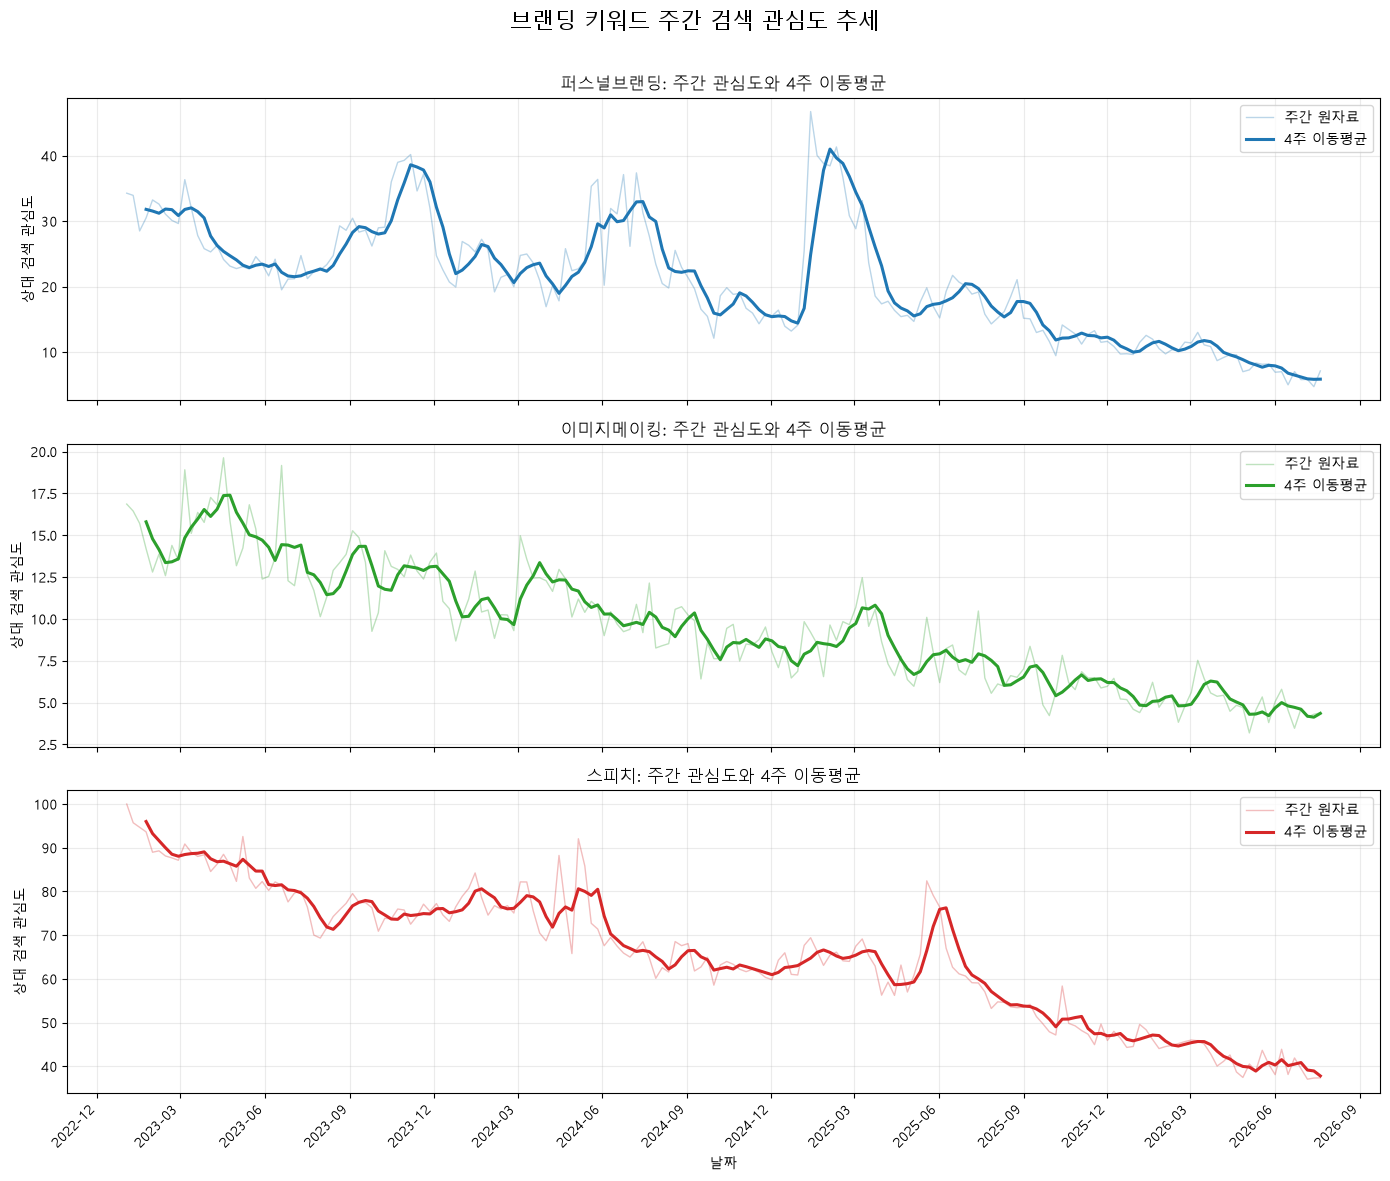

저장 완료: C:\Users\pc\Desktop\branding-trend-analysis\images\01_weekly_trend.png


In [11]:
colors = {"퍼스널브랜딩": "#1f77b4", "이미지메이킹": "#2ca02c", "스피치": "#d62728"}
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, keyword in zip(axes, keywords):
    ax.plot(df["날짜"], df[keyword], color=colors[keyword], alpha=0.30, linewidth=1.0, label="주간 원자료")
    ax.plot(df["날짜"], df[f"{keyword}_4주이동평균"], color=colors[keyword], linewidth=2.2, label="4주 이동평균")
    ax.set_title(f"{keyword}: 주간 관심도와 4주 이동평균")
    ax.set_ylabel("상대 검색 관심도")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("날짜")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")
fig.suptitle("브랜딩 키워드 주간 검색 관심도 추세", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
trend_path = IMAGE_DIR / "01_weekly_trend.png"
fig.savefig(trend_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"저장 완료: {trend_path}")

## B. 전주 대비 증감

- **증감량** = 이번 주 관심도 - 이전 주 관심도
- **변화율(%)** = 증감량 ÷ 이전 주 관심도 × 100

변화율은 이전 값이 작으면 과장될 수 있다. 이를 확인하기 위해 키워드별 이전 값의 하위 10%를 ‘상대적으로 낮은 기준값’으로 표시한다. 큰 변화율이면서 증감량은 크지 않은 후보가 있는지 별도로 확인하며, 급등·급락은 증감량을 중심으로 판단한다. 하위 10%와 상위 10%는 이상 여부를 확정하는 기준이 아니라 점검을 위한 동일한 규칙이다.

In [12]:
low_base_rows = []
exaggeration_candidates = []
threshold_rows = []

for keyword in keywords:
    previous = df[keyword].shift(1)
    delta_col = f"{keyword}_증감량"
    rate_col = f"{keyword}_변화율"
    low_col = f"{keyword}_이전값하위10%"

    df[delta_col] = df[keyword].diff()
    df[rate_col] = df[keyword].pct_change(fill_method=None) * 100
    low_threshold = previous.dropna().quantile(0.10)
    rate_threshold = df[rate_col].abs().dropna().quantile(0.90)
    delta_threshold = df[delta_col].abs().dropna().quantile(0.90)
    df[low_col] = previous.le(low_threshold)

    candidate_mask = (
        df[low_col]
        & df[rate_col].abs().ge(rate_threshold)
        & df[delta_col].abs().lt(delta_threshold)
    )
    for idx in df.index[candidate_mask]:
        exaggeration_candidates.append({
            "키워드": keyword, "날짜": df.at[idx, "날짜"],
            "이전값": previous.at[idx], "현재값": df.at[idx, keyword],
            "증감량": df.at[idx, delta_col], "변화율(%)": df.at[idx, rate_col],
        })
    threshold_rows.append({
        "키워드": keyword, "이전값 하위10% 기준": low_threshold,
        "절대 변화율 상위10% 기준": rate_threshold,
        "절대 증감량 상위10% 기준": delta_threshold,
        "과장 가능 후보 수": int(candidate_mask.sum()),
    })

threshold_table = pd.DataFrame(threshold_rows).set_index("키워드")
candidate_table = pd.DataFrame(exaggeration_candidates)
print("변화율 과장 가능성을 점검한 데이터 기반 기준:")
display(threshold_table)
print("낮은 이전 값 때문에 변화율이 상대적으로 커 보일 수 있는 후보:")
display(candidate_table if not candidate_table.empty else pd.DataFrame({"결과": ["정의한 기준에 해당하는 후보 없음"]}))

변화율 과장 가능성을 점검한 데이터 기반 기준:


,이전값 하위10% 기준,절대 변화율 상위10% 기준,절대 증감량 상위10% 기준,과장 가능 후보 수
키워드,,,,
퍼스널브랜딩,9.70143,26.08307,5.88376,5
이미지메이킹,5.06369,32.45676,2.78265,4
스피치,44.38694,10.40856,6.32962,3


낮은 이전 값 때문에 변화율이 상대적으로 커 보일 수 있는 후보:


,키워드,날짜,이전값,현재값,증감량,변화율(%)
0,퍼스널브랜딩,2025-10-13,9.43471,14.13216,4.69745,49.78902
1,퍼스널브랜딩,2026-04-27,9.57404,6.98646,-2.58758,-27.02704
2,퍼스널브랜딩,2026-06-15,6.98646,4.97611,-2.01035,-28.77494
3,퍼스널브랜딩,2026-06-22,4.97611,7.00636,2.03025,40.79994
4,퍼스널브랜딩,2026-07-20,4.69745,7.10589,2.40844,51.27122
5,이미지메이킹,2025-10-06,4.21974,5.59315,1.37341,32.54727
6,이미지메이킹,2026-05-11,3.18471,4.53821,1.35350,42.49995
7,이미지메이킹,2026-06-01,3.80175,5.05573,1.25398,32.98428
8,이미지메이킹,2026-06-29,3.46337,4.61783,1.15446,33.33343
9,스피치,2026-05-18,38.95302,43.65047,4.69745,12.05927


In [13]:
change_records = []
for keyword in keywords:
    delta_col = f"{keyword}_증감량"
    rate_col = f"{keyword}_변화율"
    for direction, idx in [("최대 증가", df[delta_col].idxmax()), ("최대 감소", df[delta_col].idxmin())]:
        change_records.append({
            "키워드": keyword, "구분": direction, "날짜": df.at[idx, "날짜"],
            "이전값": df.at[idx - 1, keyword], "현재값": df.at[idx, keyword],
            "증감량": df.at[idx, delta_col], "변화율(%)": df.at[idx, rate_col],
        })
change_extremes = pd.DataFrame(change_records)
print("증감량을 기준으로 확인한 최대 증가·감소 주:")
display(change_extremes)

증감량을 기준으로 확인한 최대 증가·감소 주:


,키워드,구분,날짜,이전값,현재값,증감량,변화율(%)
0,퍼스널브랜딩,최대 증가,2025-01-13,25.49761,46.75557,21.25796,83.37236
1,퍼스널브랜딩,최대 감소,2024-06-03,36.38535,20.20302,-16.18233,-44.47485
2,이미지메이킹,최대 증가,2024-03-04,9.29538,14.96815,5.67277,61.02784
3,이미지메이킹,최대 감소,2023-06-26,19.16799,12.28105,-6.88694,-35.92938
4,스피치,최대 증가,2024-05-06,65.78423,92.05812,26.27389,39.93950
5,스피치,최대 감소,2024-05-20,85.82802,72.71098,-13.11704,-15.28293


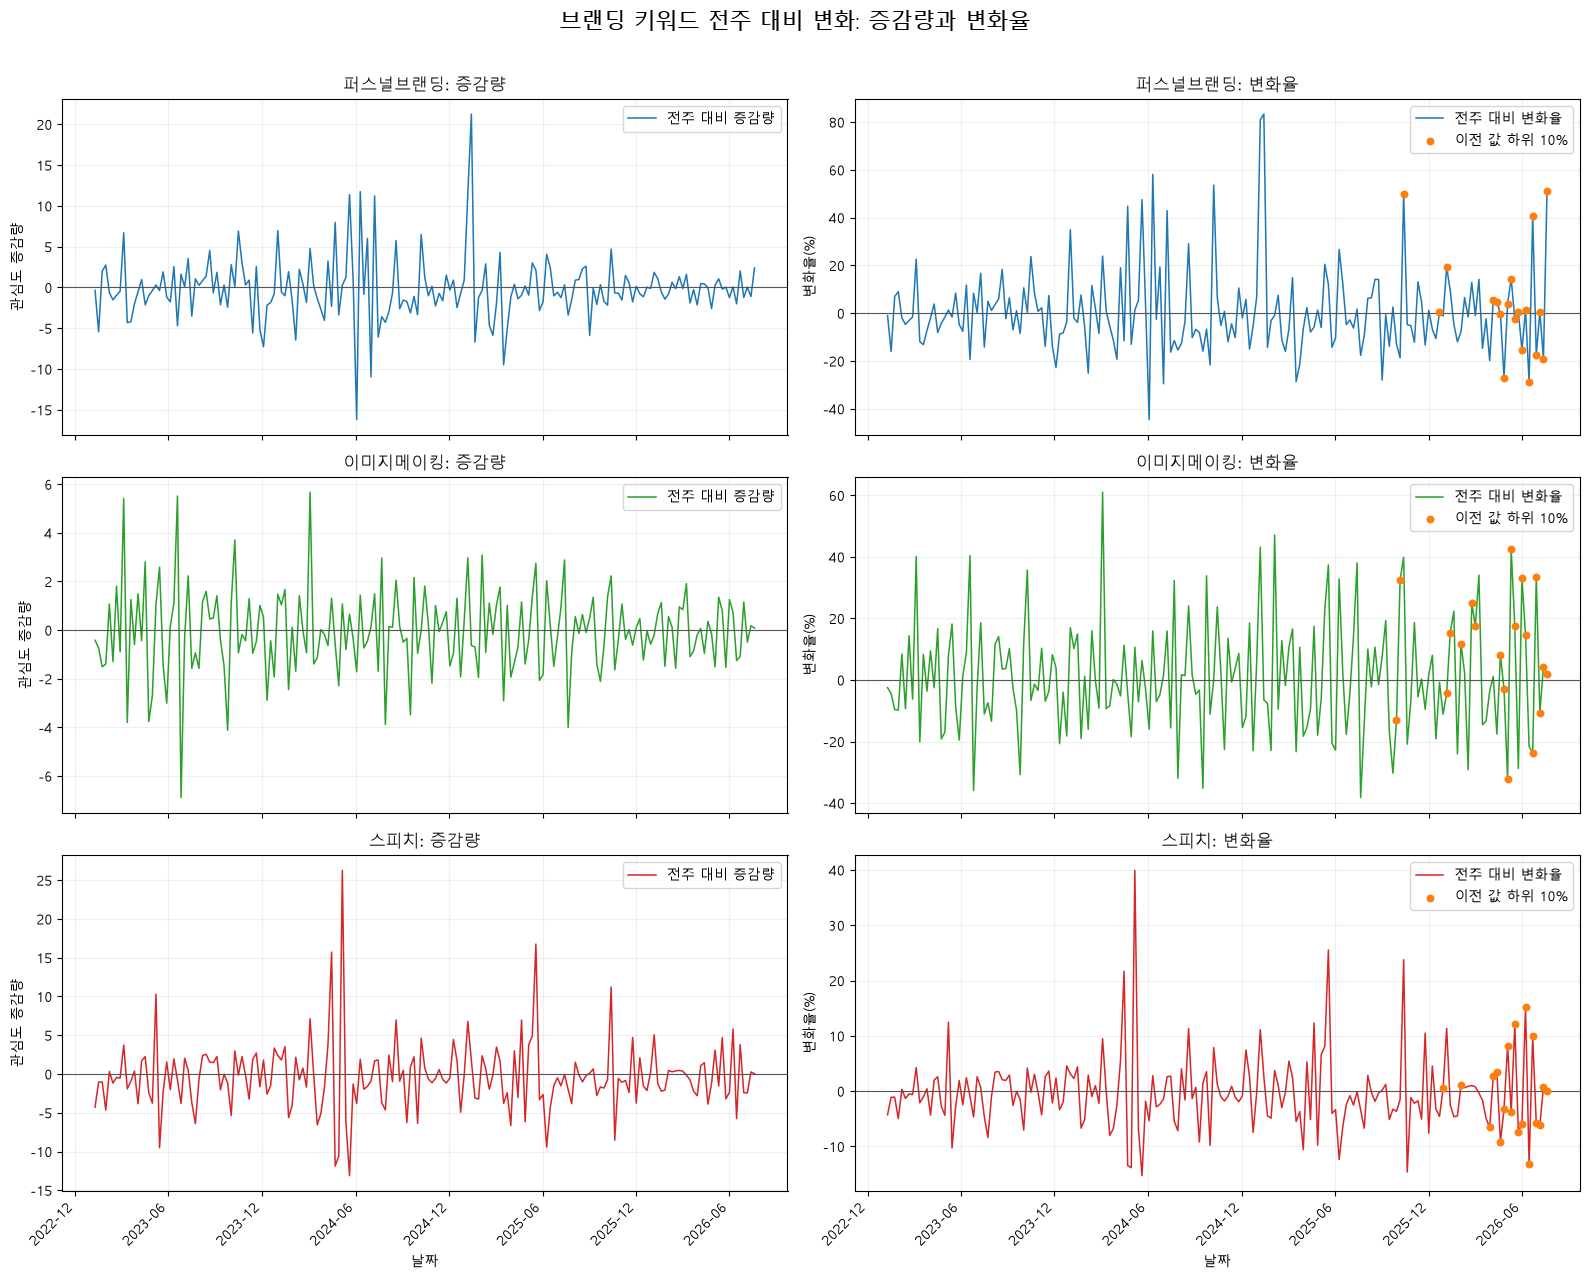

저장 완료: C:\Users\pc\Desktop\branding-trend-analysis\images\02_weekly_change.png


In [14]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13), sharex=True)

for row, keyword in enumerate(keywords):
    delta_col = f"{keyword}_증감량"
    rate_col = f"{keyword}_변화율"
    low_col = f"{keyword}_이전값하위10%"

    ax_delta, ax_rate = axes[row]
    ax_delta.plot(df["날짜"], df[delta_col], color=colors[keyword], linewidth=1.1, label="전주 대비 증감량")
    ax_delta.axhline(0, color="#555555", linewidth=0.8)
    ax_delta.set_title(f"{keyword}: 증감량")
    ax_delta.set_ylabel("관심도 증감량")
    ax_delta.grid(alpha=0.20)
    ax_delta.legend(loc="upper right")

    ax_rate.plot(df["날짜"], df[rate_col], color=colors[keyword], linewidth=1.1, label="전주 대비 변화율")
    low_mask = df[low_col] & df[rate_col].notna()
    ax_rate.scatter(df.loc[low_mask, "날짜"], df.loc[low_mask, rate_col], color="#ff7f0e", s=22, zorder=3, label="이전 값 하위 10%")
    ax_rate.axhline(0, color="#555555", linewidth=0.8)
    ax_rate.set_title(f"{keyword}: 변화율")
    ax_rate.set_ylabel("변화율(%)")
    ax_rate.grid(alpha=0.20)
    ax_rate.legend(loc="upper right")

for ax in axes[-1]:
    ax.set_xlabel("날짜")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("브랜딩 키워드 전주 대비 변화: 증감량과 변화율", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
change_path = IMAGE_DIR / "02_weekly_change.png"
fig.savefig(change_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"저장 완료: {change_path}")

## C. 월별 분석

날짜에서 연도와 월을 만들고, 각 연도·월에 속한 주간 관심도의 평균을 계산한다. 월마다 포함되는 월요일 수가 다르므로 합계 대신 평균을 사용한다.

2026년 7월에는 7월 6일·13일·20일 세 주만 있으므로 `부분월`로 표시한다. 히트맵에는 투명하게 남기지 않고 빨간 테두리로 구분하지만, 반복 월 판정에서는 완전한 12개월이 있는 2023~2025년만 사용한다.

In [15]:
df["연도"] = df["날짜"].dt.year
df["월"] = df["날짜"].dt.month

monthly_mean = df.groupby(["연도", "월"], as_index=False)[keywords].mean()
monthly_count = df.groupby(["연도", "월"]).size().rename("주간 관측 수").reset_index()
monthly = monthly_mean.merge(monthly_count, on=["연도", "월"], how="left")
monthly["부분월"] = (monthly["연도"] == 2026) & (monthly["월"] == 7)

partial_month = monthly.loc[monthly["부분월"]]
assert len(partial_month) == 1
assert int(partial_month["주간 관측 수"].iloc[0]) == 3
print("2026년 7월 부분 데이터:")
display(partial_month)
print("월별 평균 예시:")
display(monthly)

2026년 7월 부분 데이터:


,연도,월,퍼스널브랜딩,이미지메이킹,스피치,주간 관측 수,부분월
42,2026,7,5.87181,4.26619,37.22797,3,True


월별 평균 예시:


,연도,월,퍼스널브랜딩,이미지메이킹,스피치,주간 관측 수,부분월
0,2023,1,32.08996,15.19904,94.59793,5,False
1,2023,2,30.85688,13.58479,88.05732,4,False
2,2023,3,30.49362,16.53562,89.05752,4,False
3,2023,4,24.71138,17.39151,86.34056,4,False
4,2023,5,23.29219,14.39888,84.18391,5,False
5,2023,6,21.61623,14.41082,80.35927,4,False
6,2023,7,22.39251,12.13375,75.11146,5,False
7,2023,8,26.49283,12.85330,74.76114,4,False
8,2023,9,28.39868,13.18670,77.67714,4,False
9,2023,10,34.46656,12.61146,74.04458,5,False


In [16]:
# 같은 12개월을 모두 가진 2023~2025년만 반복 패턴 판정에 사용한다.
full_year_monthly = monthly[monthly["연도"].isin([2023, 2024, 2025])].copy()
assert full_year_monthly.groupby("연도")["월"].nunique().eq(12).all()

calendar_month_profile = full_year_monthly.groupby("월")[keywords].agg(["mean", "std"])
top_month_records = []
for keyword in keywords:
    for year, group in full_year_monthly.groupby("연도"):
        for rank, (_, row) in enumerate(group.nlargest(3, keyword).iterrows(), start=1):
            top_month_records.append({"키워드": keyword, "연도": year, "월": int(row["월"]), "연도 내 순위": rank, "월평균": row[keyword]})

top_months_by_year = pd.DataFrame(top_month_records)
repeat_counts = (top_months_by_year.groupby(["키워드", "월"]).size().rename("상위3개월 포함 연도 수").reset_index())
recurring_high_months = repeat_counts[repeat_counts["상위3개월 포함 연도 수"] >= 2].copy()

print("완전한 3개 연도에서 각 키워드의 연도별 상위 3개월:")
display(top_months_by_year)
print("2개 이상 연도에서 상위 3개월에 반복 포함된 달:")
display(recurring_high_months if not recurring_high_months.empty else pd.DataFrame({"결과": ["해당 월 없음"]}))
print("2023~2025년 기준 월별 평균과 표준편차:")
display(calendar_month_profile)

완전한 3개 연도에서 각 키워드의 연도별 상위 3개월:


,키워드,연도,월,연도 내 순위,월평균
0,퍼스널브랜딩,2023,11,1,35.99223
1,퍼스널브랜딩,2023,10,2,34.46656
2,퍼스널브랜딩,2023,1,3,32.08996
3,퍼스널브랜딩,2024,6,1,30.09554
4,퍼스널브랜딩,2024,5,2,29.59295
5,퍼스널브랜딩,2024,7,3,29.19187
6,퍼스널브랜딩,2025,1,1,37.77866
7,퍼스널브랜딩,2025,2,2,36.83320
8,퍼스널브랜딩,2025,3,3,24.30732
9,이미지메이킹,2023,4,1,17.39151


2개 이상 연도에서 상위 3개월에 반복 포함된 달:


,키워드,월,상위3개월 포함 연도 수
0,스피치,1,3
2,스피치,3,2
3,스피치,5,2
5,이미지메이킹,1,3
7,이미지메이킹,3,3
8,이미지메이킹,4,2
9,퍼스널브랜딩,1,2


2023~2025년 기준 월별 평균과 표준편차:


퍼스널브랜딩            이미지메이킹              스피치         
       mean      std     mean     std     mean      std
월                                                      
1  32.04750  5.75251 11.58174 3.37433 80.20401 14.00871
2  29.43205  8.20685 10.89935 2.32768 76.37009 11.57368
3  26.12758  3.79847 13.42622 3.07725 76.96291 12.42944
4  20.53808  4.21538 12.09394 5.19343 73.18736 13.75412
5  23.38906  6.15603 11.02972 3.27523 78.88899  6.25697
6  23.70222  5.64707 10.42960 3.63456 71.18497  8.00945
7  22.86922  6.09828  9.87227 2.30880 65.74475  9.02265
8  22.12878  4.38914  9.56906 3.27680 64.63807 10.34193
9  19.68385  7.73633  9.33850 3.51982 64.07311 13.19662
10 21.98513 11.30150  9.16998 3.17855 62.78695 11.45489
11 21.27952 12.86346  9.44466 3.39230 61.26758 13.66505
12 15.63428  5.90098  7.97372 2.84070 61.19924 14.80671

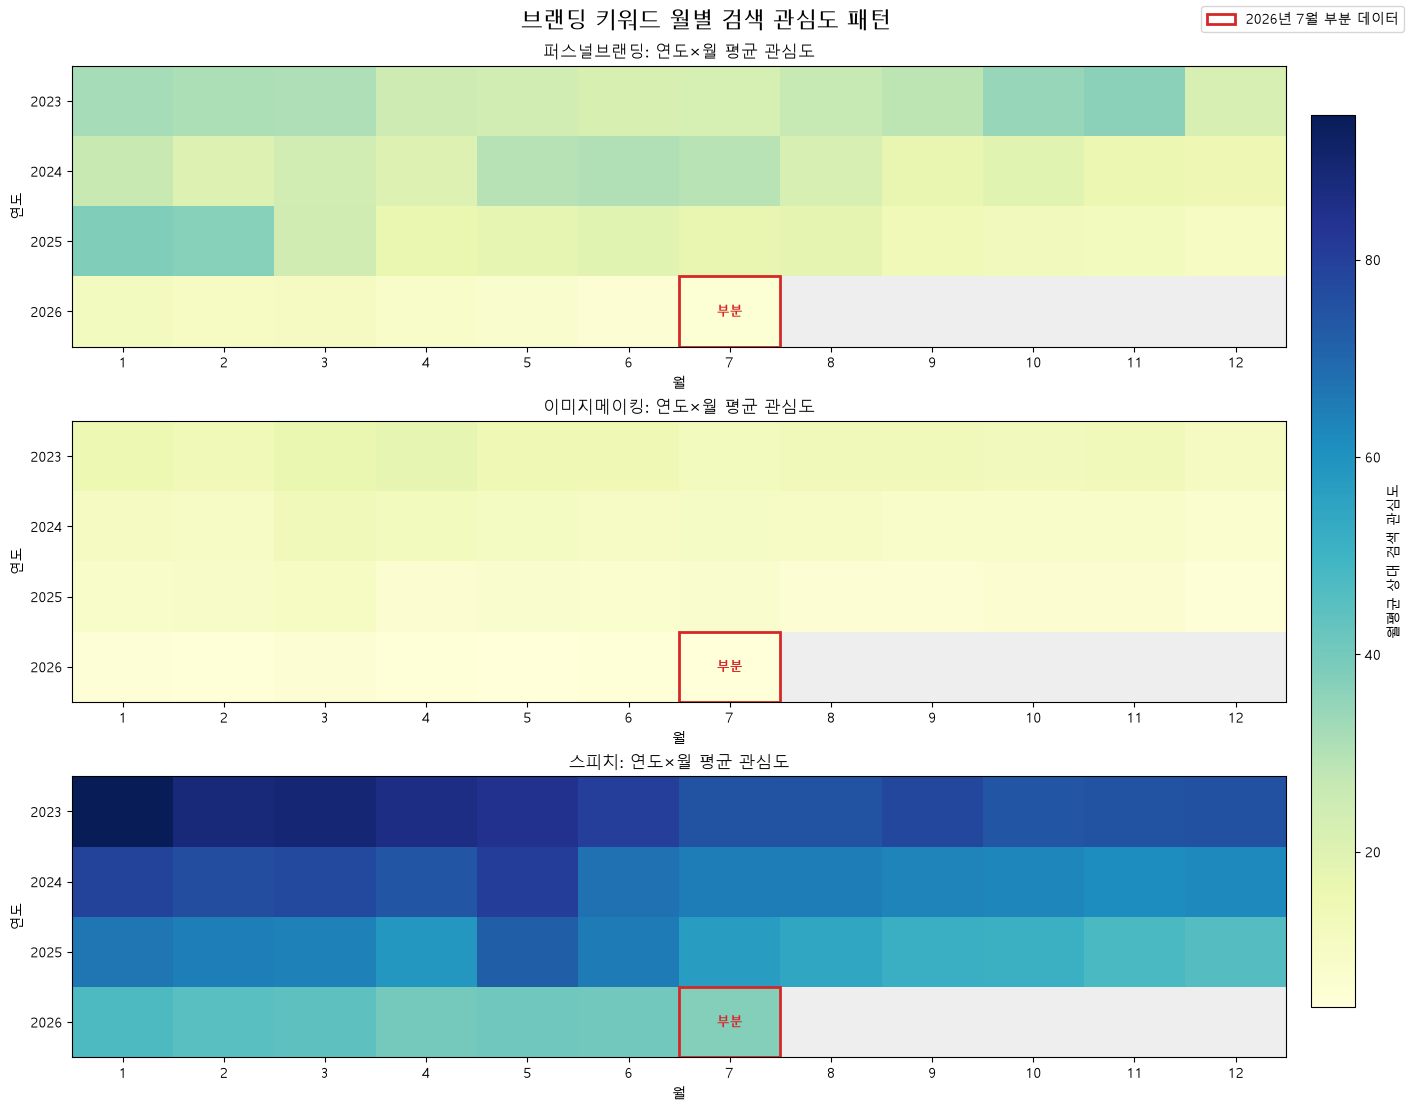

저장 완료: C:\Users\pc\Desktop\branding-trend-analysis\images\03_monthly_pattern.png


In [17]:
years = list(range(int(monthly["연도"].min()), int(monthly["연도"].max()) + 1))
months = list(range(1, 13))
vmin = monthly[keywords].min().min()
vmax = monthly[keywords].max().max()
cmap = plt.colormaps["YlGnBu"].copy()
cmap.set_bad(color="#eeeeee")

fig, axes = plt.subplots(3, 1, figsize=(14, 11), constrained_layout=True)
images = []
for ax, keyword in zip(axes, keywords):
    pivot = monthly.pivot(index="연도", columns="월", values=keyword).reindex(index=years, columns=months)
    masked = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
    image = ax.imshow(masked, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    images.append(image)
    ax.set_title(f"{keyword}: 연도×월 평균 관심도")
    ax.set_xlabel("월")
    ax.set_ylabel("연도")
    ax.set_xticks(range(12), [str(month) for month in months])
    ax.set_yticks(range(len(years)), [str(year) for year in years])

    # 2026년 7월(열 인덱스 6)에 빨간 테두리와 '부분' 표시를 추가한다.
    partial_row = years.index(2026)
    ax.add_patch(patches.Rectangle((5.5, partial_row - 0.5), 1, 1, fill=False, edgecolor="#d62728", linewidth=2.0))
    ax.text(6, partial_row, "부분", ha="center", va="center", color="#d62728", fontsize=9, fontweight="bold")

cbar = fig.colorbar(images[0], ax=axes, location="right", shrink=0.90, pad=0.02)
cbar.set_label("월평균 상대 검색 관심도")
partial_legend = patches.Patch(facecolor="none", edgecolor="#d62728", linewidth=2, label="2026년 7월 부분 데이터")
fig.legend(handles=[partial_legend], loc="outside upper right")
fig.suptitle("브랜딩 키워드 월별 검색 관심도 패턴", fontsize=16)
monthly_path = IMAGE_DIR / "03_monthly_pattern.png"
fig.savefig(monthly_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"저장 완료: {monthly_path}")

## 실제 계산 결과 1~4: 평균·최솟값·최댓값과 주요 주간 변화

아래 결과는 데이터에서 직접 계산한 값이다. 최고 관심도 주는 원자료의 최댓값, 최대 증가·감소 주는 변화율이 아닌 **증감량**을 기준으로 선택한다.

In [18]:
summary_table = df[keywords].agg(["mean", "min", "max"]).T.rename(columns={"mean": "전체 평균", "min": "최솟값", "max": "최댓값"})
peak_records = []
for keyword in keywords:
    peak_idx = df[keyword].idxmax()
    peak_records.append({"키워드": keyword, "최고 관심도 주": df.at[peak_idx, "날짜"], "관심도": df.at[peak_idx, keyword]})
peak_weeks = pd.DataFrame(peak_records)

print("1. 키워드별 전체 평균, 최소값, 최대값")
display(summary_table)
print("2. 키워드별 관심도가 가장 높았던 주")
display(peak_weeks)
print("3~4. 키워드별 전주 대비 증감량이 가장 컸던 주와 감소량이 가장 컸던 주")
display(change_extremes)

1. 키워드별 전체 평균, 최소값, 최대값


,전체 평균,최솟값,최댓값
퍼스널브랜딩,20.93060,4.69745,46.75557
이미지메이킹,9.53370,3.18471,19.62579
스피치,65.38657,37.04219,100.00000


2. 키워드별 관심도가 가장 높았던 주


,키워드,최고 관심도 주,관심도
0,퍼스널브랜딩,2025-01-13,46.75557
1,이미지메이킹,2023-04-17,19.62579
2,스피치,2023-01-02,100.00000


3~4. 키워드별 전주 대비 증감량이 가장 컸던 주와 감소량이 가장 컸던 주


,키워드,구분,날짜,이전값,현재값,증감량,변화율(%)
0,퍼스널브랜딩,최대 증가,2025-01-13,25.49761,46.75557,21.25796,83.37236
1,퍼스널브랜딩,최대 감소,2024-06-03,36.38535,20.20302,-16.18233,-44.47485
2,이미지메이킹,최대 증가,2024-03-04,9.29538,14.96815,5.67277,61.02784
3,이미지메이킹,최대 감소,2023-06-26,19.16799,12.28105,-6.88694,-35.92938
4,스피치,최대 증가,2024-05-06,65.78423,92.05812,26.27389,39.93950
5,스피치,최대 감소,2024-05-20,85.82802,72.71098,-13.11704,-15.28293


## 실제 계산 결과 5: 반복적으로 높은 월의 기초 결과

2023~2025년 각각에서 월평균 상위 3개월을 구한 뒤, 같은 달이 3개 연도 중 몇 번 포함됐는지 센다. 2회 이상이면 `반복 고관심 후보 월`로 표시한다. 이는 반복 여부를 살펴보는 기초 기준이며 통계적으로 확정된 계절성이라는 뜻은 아니다.

In [19]:
for keyword in keywords:
    result = recurring_high_months[recurring_high_months["키워드"] == keyword]
    if result.empty:
        print(f"{keyword}: 2개 이상 연도에서 반복된 상위 3개월이 없음")
    else:
        month_text = ", ".join(f"{int(row['월'])}월({int(row['상위3개월 포함 연도 수'])}/3년)" for _, row in result.sort_values(["상위3개월 포함 연도 수", "월"], ascending=[False, True]).iterrows())
        print(f"{keyword}: {month_text}")

퍼스널브랜딩: 1월(2/3년)
이미지메이킹: 1월(3/3년), 3월(3/3년), 4월(2/3년)
스피치: 1월(3/3년), 3월(2/3년), 5월(2/3년)


## 실제 계산 결과 6: 4주 이동평균 우선순위 변화

이동평균이 모두 계산되는 네 번째 주부터 세 값의 순위를 비교한다. 가장 높은 키워드가 바뀌는 날짜를 주요 우선순위 변화로 보고, 세부 비교를 위해 키워드 쌍별 교차 시점도 확인한다.

In [20]:
ma_table = df.set_index("날짜")[moving_average_columns].dropna().copy()
ma_table.columns = keywords
top_keyword = ma_table.idxmax(axis=1)
top_change_mask = top_keyword.ne(top_keyword.shift(1))
top_change_mask.iloc[0] = False
top_priority_changes = pd.DataFrame({"날짜": ma_table.index[top_change_mask], "새 1순위": top_keyword[top_change_mask].values})

pairwise_records = []
for i, first in enumerate(keywords):
    for second in keywords[i + 1:]:
        first_is_higher = ma_table[first] > ma_table[second]
        cross_mask = first_is_higher.ne(first_is_higher.shift(1))
        cross_mask.iloc[0] = False
        for date in ma_table.index[cross_mask]:
            higher = first if first_is_higher.loc[date] else second
            lower = second if first_is_higher.loc[date] else first
            pairwise_records.append({"날짜": date, "비교": f"{first} vs {second}", "교차 후 순서": f"{higher} > {lower}"})
pairwise_crossovers = pd.DataFrame(pairwise_records).sort_values("날짜").reset_index(drop=True) if pairwise_records else pd.DataFrame(columns=["날짜", "비교", "교차 후 순서"])

print(f"첫 4주 이동평균 계산일의 1순위: {top_keyword.index[0]:%Y-%m-%d}, {top_keyword.iloc[0]}")
print(f"이후 1순위 변경 횟수: {len(top_priority_changes)}회")
display(top_priority_changes if not top_priority_changes.empty else pd.DataFrame({"결과": ["1순위 변경 없음"]}))
print(f"키워드 쌍별 4주 이동평균 교차 횟수: {len(pairwise_crossovers)}회")
display(pairwise_crossovers if not pairwise_crossovers.empty else pd.DataFrame({"결과": ["교차 없음"]}))

첫 4주 이동평균 계산일의 1순위: 2023-01-23, 스피치
이후 1순위 변경 횟수: 0회


,결과
0,1순위 변경 없음


키워드 쌍별 4주 이동평균 교차 횟수: 0회


,결과
0,교차 없음


## Fact 정리 원칙과 추가 검토 사항

- 위 표와 그래프에서 직접 계산된 날짜, 값, 순위와 반복 횟수만 `Fact`로 사용한다.
- 특정 시점에 값이 움직인 외부 원인은 이 데이터만으로 알 수 없으므로 설명하지 않는다.
- 반복 고관심 후보 월은 3개 완전 연도만 사용한 기초 결과다. 더 긴 기간에서 유지되는지는 추가 자료가 필요하다.
- 2026년 7월은 세 주만 포함된 부분 데이터이므로 완전한 월과 동등하게 비교하지 않는다.
- 관심도는 상대 지표이므로 실제 검색 건수, 검색 시장 규모 또는 세 키워드의 실제 점유율로 해석하지 않는다.

In [21]:
expected_images = [trend_path, change_path, monthly_path]
missing_images = [str(path) for path in expected_images if not path.exists() or path.stat().st_size == 0]
assert not missing_images, f"생성되지 않은 그래프가 있습니다: {missing_images}"
print("검증 완료: 데이터 품질 검사와 분석 계산이 오류 없이 끝났습니다.")
for path in expected_images:
    print(f"- {path.relative_to(PROJECT_DIR)} ({path.stat().st_size:,} bytes)")

검증 완료: 데이터 품질 검사와 분석 계산이 오류 없이 끝났습니다.
- images\01_weekly_trend.png (436,133 bytes)
- images\02_weekly_change.png (696,223 bytes)
- images\03_monthly_pattern.png (103,290 bytes)


# 보너스 분석: 스피치 시계열 분해

스피치 주간 관심도를 관측값, 추세, 계절 성분, 잔차로 나누어 살펴본다. `period=52`는 **연간 유사 주기 탐색을 위한 가정**이다. 약 3년 7개월의 데이터에서 52주 패턴이 실제로 안정적으로 반복된다고 확정하는 검정은 아니므로, 분해 결과는 계절성의 존재를 단정하지 않고 탐색적으로 해석한다.

- `DatetimeIndex`에 `W-MON` 빈도를 명시해 매주 월요일 관측값임을 보장한다.
- 관심도 수준의 변화량을 분리하기 위해 `model="additive"`를 사용한다.
- `extrapolate_trend`는 지정하지 않아 기본 경계 결측값을 유지한다. 따라서 추세와 잔차의 유효 구간은 전체 관측 기간보다 짧다.


In [22]:
import statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose

speech_series = (
    df.set_index("날짜")["스피치"]
    .sort_index()
    .asfreq("W-MON")
)

assert speech_series.index.freqstr == "W-MON"
assert not speech_series.isna().any(), "주간 빈도 변환 후 결측 주가 발견되었습니다."
assert len(speech_series) >= 2 * 52, "52주 주기 분해에는 최소 두 주기의 관측값이 필요합니다."

speech_decomposition = seasonal_decompose(
    speech_series,
    model="additive",
    period=52,
)

assert speech_decomposition.trend.isna().any(), "기본 경계 결측값이 유지되지 않았습니다."
print(f"statsmodels 버전: {statsmodels.__version__}")
print(f"관측 기간: {speech_series.index.min():%Y-%m-%d} ~ {speech_series.index.max():%Y-%m-%d}")
print(f"관측값 수: {len(speech_series):,}개, 빈도: {speech_series.index.freqstr}")
print(f"결측 주 수: {speech_series.isna().sum()}개")
print(f"분해 가정: additive, period=52 (연간 유사 주기 탐색)")
print(f"추세 경계 결측값 수: {speech_decomposition.trend.isna().sum()}개")

statsmodels 버전: 0.15.0
관측 기간: 2023-01-02 ~ 2026-07-20
관측값 수: 186개, 빈도: W-MON
결측 주 수: 0개
분해 가정: additive, period=52 (연간 유사 주기 탐색)
추세 경계 결측값 수: 52개


## 향후 AI 비서 요약 정보 후보

아래 값은 향후 미션 2의 데이터 요약 설계에 사용할 수 있는 후보이며, 현재 단계에서는 AI 비서를 구현하지 않는다. 최근 추세의 방향은 단일 시점의 우연한 움직임을 줄이기 위해 **마지막 유효 4주 추세 평균**과 **그 직전 유효 4주 추세 평균**을 비교해 상승·하락·유지로 구분한다. `np.isclose` 범위에서 두 평균이 같으면 유지로 처리한다.


In [23]:
valid_trend = speech_decomposition.trend.dropna()
valid_seasonal = speech_decomposition.seasonal.dropna()
valid_residual = speech_decomposition.resid.dropna()

recent_trend_mean = valid_trend.iloc[-4:].mean()
previous_trend_mean = valid_trend.iloc[-8:-4].mean()
if np.isclose(recent_trend_mean, previous_trend_mean):
    recent_trend_direction = "유지"
elif recent_trend_mean > previous_trend_mean:
    recent_trend_direction = "상승"
else:
    recent_trend_direction = "하락"

seasonal_max = valid_seasonal.max()
seasonal_min = valid_seasonal.min()
seasonal_max_dates = valid_seasonal.index[np.isclose(valid_seasonal.to_numpy(), seasonal_max)]
seasonal_min_dates = valid_seasonal.index[np.isclose(valid_seasonal.to_numpy(), seasonal_min)]
seasonal_max_date = seasonal_max_dates[0]
seasonal_min_date = seasonal_min_dates[0]
seasonal_max_cycle_week = speech_series.index.get_loc(seasonal_max_date) % 52 + 1
seasonal_min_cycle_week = speech_series.index.get_loc(seasonal_min_date) % 52 + 1

largest_residual_date = valid_residual.abs().idxmax()
largest_residual_value = valid_residual.loc[largest_residual_date]

agent_summary_candidates = pd.DataFrame({
    "요약 항목": [
        "유효 trend 시작일",
        "유효 trend 종료일",
        "유효 trend 평균",
        "최근 유효 trend 값",
        "최근 trend 방향",
        "seasonal 최대값",
        "seasonal 최대 대표 날짜 / 52주 내 위치",
        "seasonal 최소값",
        "seasonal 최소 대표 날짜 / 52주 내 위치",
        "residual 절대값 최대 날짜",
        "해당 residual 값",
    ],
    "계산 결과": [
        valid_trend.index.min().strftime("%Y-%m-%d"),
        valid_trend.index.max().strftime("%Y-%m-%d"),
        f"{valid_trend.mean():.5f}",
        f"{valid_trend.iloc[-1]:.5f}",
        recent_trend_direction,
        f"{seasonal_max:.5f}",
        f"{seasonal_max_date:%Y-%m-%d} / {seasonal_max_cycle_week}주차",
        f"{seasonal_min:.5f}",
        f"{seasonal_min_date:%Y-%m-%d} / {seasonal_min_cycle_week}주차",
        largest_residual_date.strftime("%Y-%m-%d"),
        f"{largest_residual_value:.5f}",
    ],
})

print("[향후 AI 비서 요약 정보 후보]")
display(agent_summary_candidates)
print(f"방향 비교 기준 - 직전 4주 평균: {previous_trend_mean:.5f}, 마지막 4주 평균: {recent_trend_mean:.5f}")
print("seasonal 최대 날짜 전체:", ", ".join(date.strftime("%Y-%m-%d") for date in seasonal_max_dates))
print("seasonal 최소 날짜 전체:", ", ".join(date.strftime("%Y-%m-%d") for date in seasonal_min_dates))

[향후 AI 비서 요약 정보 후보]


,요약 항목,계산 결과
0,유효 trend 시작일,2023-07-03
1,유효 trend 종료일,2026-01-19
2,유효 trend 평균,65.95827
3,최근 유효 trend 값,45.85527
4,최근 trend 방향,하락
5,seasonal 최대값,11.64107
6,seasonal 최대 대표 날짜 / 52주 내 위치,2023-05-22 / 21주차
7,seasonal 최소값,-7.82744
8,seasonal 최소 대표 날짜 / 52주 내 위치,2023-07-31 / 31주차
9,residual 절대값 최대 날짜,2024-04-15


방향 비교 기준 - 직전 4주 평균: 48.17280, 마지막 4주 평균: 46.46896
seasonal 최대 날짜 전체: 2023-05-22, 2024-05-20, 2025-05-19, 2026-05-18
seasonal 최소 날짜 전체: 2023-07-31, 2024-07-29, 2025-07-28


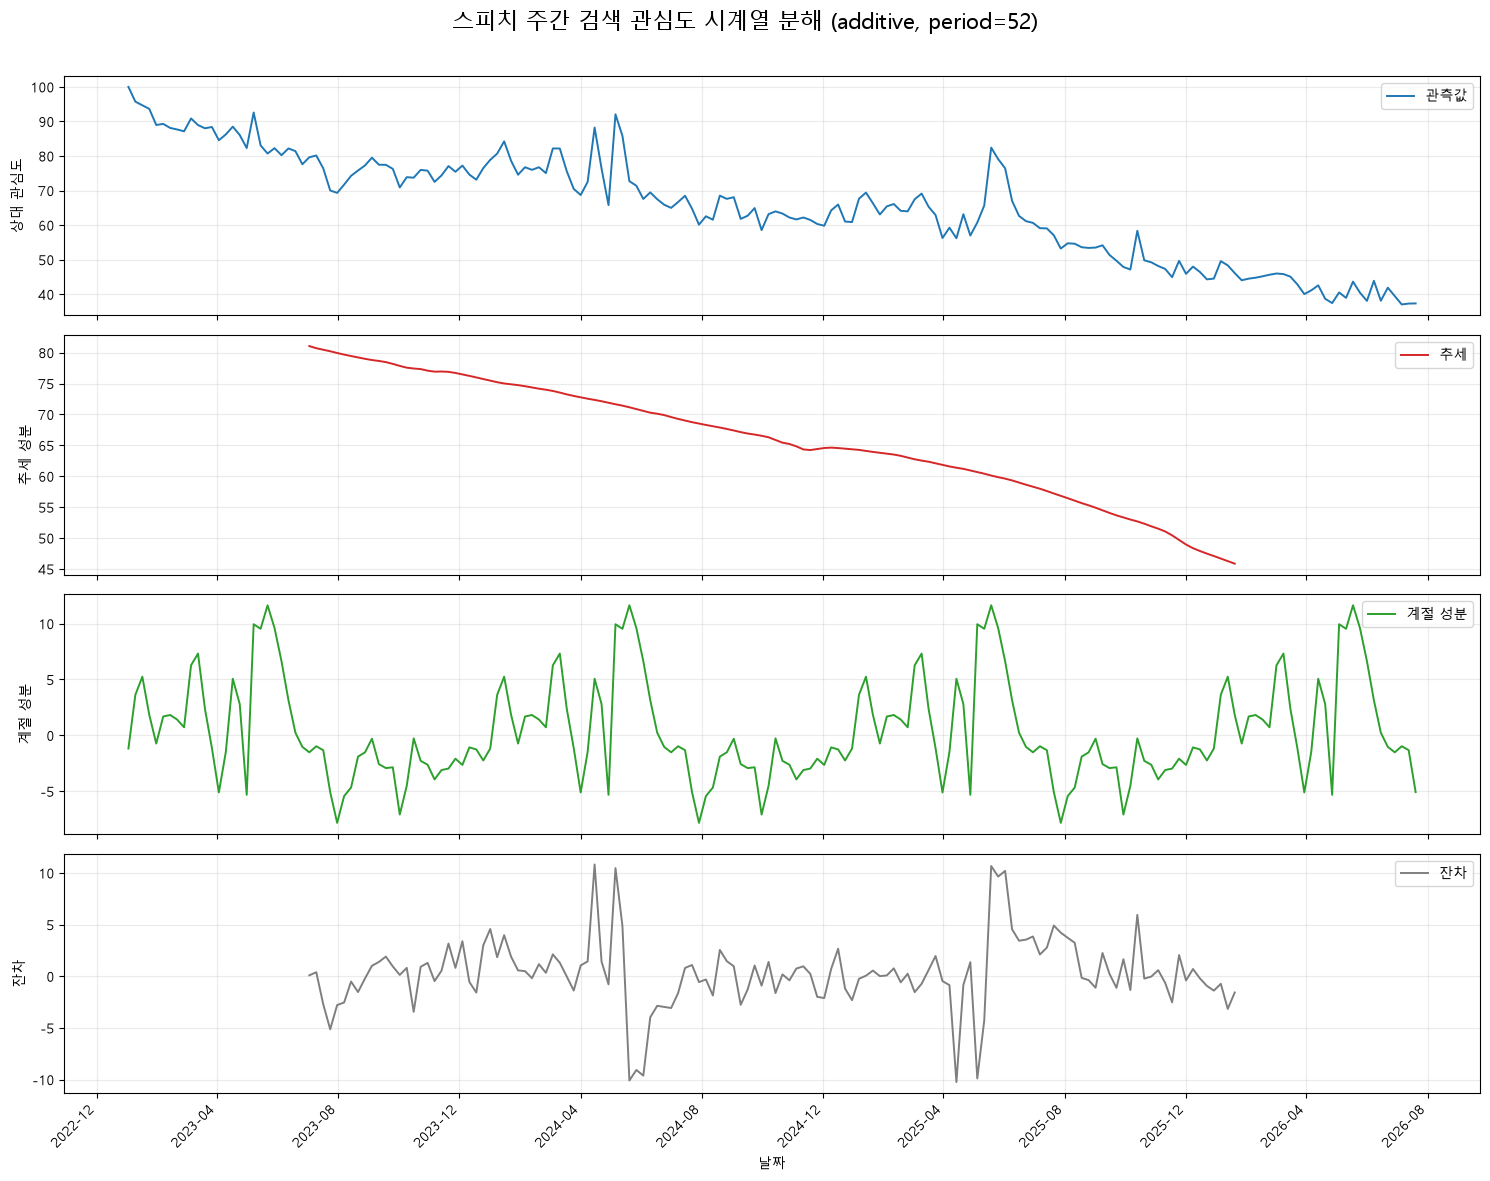

저장 완료: images\04_speech_decomposition.png (334,929 bytes)


In [24]:
decomposition_path = IMAGE_DIR / "04_speech_decomposition.png"
component_specs = [
    (speech_decomposition.observed, "관측값", "상대 관심도", "#1f77b4"),
    (speech_decomposition.trend, "추세", "추세 성분", "#d62728"),
    (speech_decomposition.seasonal, "계절 성분", "계절 성분", "#2ca02c"),
    (speech_decomposition.resid, "잔차", "잔차", "#7f7f7f"),
]

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
for ax, (component, label, ylabel, color) in zip(axes, component_specs):
    ax.plot(component.index, component.values, color=color, linewidth=1.4, label=label)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("날짜")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.suptitle("스피치 주간 검색 관심도 시계열 분해 (additive, period=52)", fontsize=16)
fig.autofmt_xdate(rotation=45)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(decomposition_path, dpi=180, bbox_inches="tight")
plt.show()

assert decomposition_path.exists() and decomposition_path.stat().st_size > 0
print(f"저장 완료: {decomposition_path.relative_to(PROJECT_DIR)} ({decomposition_path.stat().st_size:,} bytes)")

## 해석 원칙

- **Fact:** 각 성분의 값, 유효 기간, 극값 날짜는 위 계산에서 직접 확인한다.
- **Interpretation (Hypothesis):** 추세 방향이나 52주 계절 성분은 콘텐츠 기획 가설을 만드는 단서로만 사용한다.
- **Limitation:** 52주가 달력의 연도와 완전히 일치하지 않고 관측된 반복 횟수도 약 3.6회에 불과하다. 단순 분해는 계절성의 통계적 유의성을 검정하지 않으며, 외부 사건이나 검색 원인을 설명하지도 않는다.
